# Deep Learning Assignment 2

In [44]:
from pathlib import Path
import h5py
import numpy as np

from scipy.signal import resample

import torch
import torch.nn as nn

In [45]:
data_root = Path('..') / 'data' / 'raw' / 'Final Project data'
h5_files = sorted(data_root.rglob('*.h5'))

if not h5_files:
    raise FileNotFoundError(f'No .h5 files found under {data_root}')

def get_dataset_name(file_name_with_dir: Path) -> str:
    file_name_without_dir = file_name_with_dir.as_posix().split('/')[-1]
    temp = file_name_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

filename_path = h5_files[0]
print(f'Loading: {filename_path}')

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    obj = f.get(dataset_name)
    if obj is None:
        raise ValueError(f"Dataset '{dataset_name}' not found in {filename_path}")
    if not isinstance(obj, h5py.Dataset):
        raise ValueError(f"Expected h5py.Dataset, got {type(obj)}")
    dataset: h5py.Dataset = obj
    matrix: np.ndarray = dataset[()]
    print(type(matrix))
    print(matrix.shape)

Loading: ..\data\raw\Final Project data\Cross\test1\rest_162935_1.h5
<class 'numpy.ndarray'>
(248, 35624)


In [46]:
# Step 1: Inspect the available files and labels
# This cell is a placeholder for summarizing the dataset structure and label mapping.
file_summary = {
    "task_types": ["rest", "task_motor", "task_story_math", "task_working_memory"],
    "classification_targets": ["rest", "math", "memory", "motor"],
}
file_summary

{'task_types': ['rest',
  'task_motor',
  'task_story_math',
  'task_working_memory'],
 'classification_targets': ['rest', 'math', 'memory', 'motor']}

In [47]:
# Step 2: Preprocess the time series data
# Apply the preprocessing required by the assignment, such as normalization.
# The actual preprocessing logic can be added here. you can save this data in a file under ../data/processed/ for later use

def min_max_normalize(matrix: np.ndarray) -> np.ndarray:
    min_val = np.min(matrix, axis=0)
    max_val = np.max(matrix, axis=0)
    normalized_matrix = (matrix - min_val) / (max_val - min_val)
    return normalized_matrix

def z_score_normalize(matrix: np.ndarray) -> np.ndarray:
    mean = np.mean(matrix, axis=0)
    std = np.std(matrix, axis=0)
    normalized_matrix = (matrix - mean) / (std)
    return normalized_matrix

def preprocess_matrix(matrix: np.ndarray) -> np.ndarray:
    processed_matrix = matrix.astype(np.float32)

    processed_matrix = z_score_normalize(processed_matrix)
    return processed_matrix

processed_matrix = preprocess_matrix(matrix)

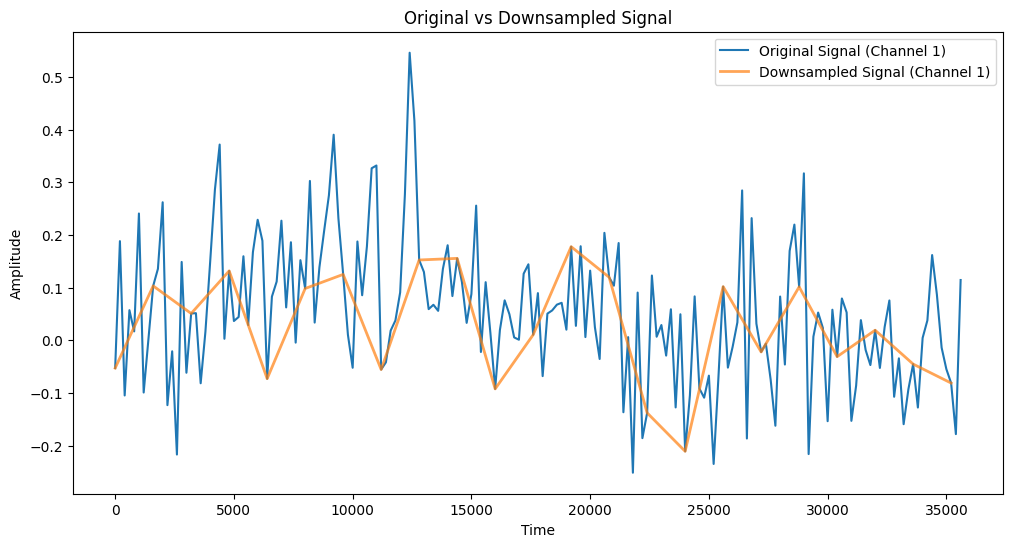

Original shape: (248, 35624), Downsampled shape: (248, 4453)


In [61]:
# Step 3: Downsample the signals
# Add the downsampling strategy here to reduce the temporal resolution of each recording.

def visualize_downsampling(original: np.ndarray, downsampled: np.ndarray, factor: int):
    import matplotlib.pyplot as plt
    time_original = np.arange(original.shape[1])
    time_downsampled = np.arange(downsampled.shape[1]) * factor
    
    plt.figure(figsize=(12, 6))
    plt.plot(time_original[::200], original[0, :][::200], label='Original Signal (Channel 1)', alpha=1)
    plt.plot(time_downsampled[::200], downsampled[0, :][::200], label='Downsampled Signal (Channel 1)', alpha=0.7, linewidth=2)
    plt.title('Original vs Downsampled Signal')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()

def downsample_matrix(matrix: np.ndarray, downsample_rate=250, original_rate=2034) -> np.ndarray:
    factor = original_rate // downsample_rate
    visualize_downsampling(processed_matrix, downsampled_matrix, factor)
    return matrix[:, ::factor]

downsampled_matrix = downsample_matrix(processed_matrix)

print(f'Original shape: {processed_matrix.shape}, Downsampled shape: {downsampled_matrix.shape}')

In [21]:
# Step 4: Prepare the intra-subject dataset
# Build the train/test split using recordings from the same subject.
intra_subject_data = {
    "train": None,
    "test": None,
}
intra_subject_data

{'train': None, 'test': None}

In [22]:
# Step 5: Prepare the cross-subject dataset
# Build the train/test split using different subjects for train and test.
cross_subject_data = {
    "train": None,
    "test": None,
}
cross_subject_data

{'train': None, 'test': None}

In [ ]:
# Step 6: Define the model architecture
# Implement the deep learning model chosen for the assignment here.

class CNN_GRU_Classifier(nn.Module):
    def __init__(self, in_channels=248, num_classes=4, dropout=0.3, kernel_size=3, hidden_dim=64, negative_slope=0.01):
        super(CNN_GRU_Classifier, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=kernel_size, padding=kernel_size // 2),  # [B, 128, T]
            nn.InstanceNorm1d(128),
            nn.LeakyReLU(negative_slope),
            nn.AvgPool1d(2),  # Downsample T → T/2

            nn.Conv1d(128, 256, kernel_size=kernel_size, padding=kernel_size // 2),  # [B, 256, T/2]
            nn.InstanceNorm1d(256),
            nn.LeakyReLU(negative_slope),
            nn.AvgPool1d(2)  # T/2 → T/4
        )

        # GRU input size = number of conv output channels
        self.gru = nn.GRU(input_size=256, hidden_size=hidden_dim, num_layers=1,
                          batch_first=True, bidirectional=False)

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.LeakyReLU(negative_slope),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):  # x: [B, 248, 2000]
        x = self.conv(x)          # [B, 256, T']
        x = x.permute(0, 2, 1)    # [B, T', 256] — GRU expects time last
        _, h_n = self.gru(x)      # h_n: [1, B, hidden_dim]
        h_n = h_n.squeeze(0)      # [B, hidden_dim]
        out = self.fc(h_n)        # [B, num_classes]
        return out
    
class CNN_1D_Classifier(nn.Module):
    def __init__(self, in_channels=248, num_classes=4, dropout=0.3, kernel_size=3, negative_slope=0.01):
        super(CNN_1D_Classifier, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=kernel_size, stride=1, padding=2),  # output: [B, 128, T]
            nn.BatchNorm1d(128),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.AvgPool1d(kernel_size=2),  # halve the time dimension

            nn.Conv1d(128, 256, kernel_size=kernel_size, stride=1, padding=2),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.AdaptiveAvgPool1d(1)  # output: [B, 256, 1]
        )
        self.fc = nn.Sequential(
            nn.Flatten(),             # [B, 256]
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):  # x: [B, C, T]
        x = self.conv(x)
        x = self.fc(x)
        return x


def build_model(input_shape):
    model = None
    return model

model = build_model(downsampled_matrix.shape)

In [24]:
# Step 7: Train and evaluate the intra-subject model
# Fit the model on the intra-subject split and record the evaluation metrics.
intra_subject_results = {
    "train_accuracy": None,
    "test_accuracy": None,
}
intra_subject_results

{'train_accuracy': None, 'test_accuracy': None}

In [25]:
# Step 8: Train and evaluate the cross-subject model
# Fit the same model on the cross-subject split and compare the results.
cross_subject_results = {
    "train_accuracy": None,
    "test_accuracy": None,
}
cross_subject_results

{'train_accuracy': None, 'test_accuracy': None}

In [26]:
# Step 9: Compare results and try an alternative approach
# Use this cell to compare both settings and implement a stronger baseline if needed.
comparison = {
    "intra_subject": intra_subject_results,
    "cross_subject": cross_subject_results,
}
comparison

{'intra_subject': {'train_accuracy': None, 'test_accuracy': None},
 'cross_subject': {'train_accuracy': None, 'test_accuracy': None}}